In [16]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [18]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


for batchImages, batchLabels in train_loader:
    batchImages = batchImages.view(batchImages.size(0), -1) ## flatten the images

In [20]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

In [21]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [22]:
noise_dim = 100
D = Discriminator()
G = Generator(noise_dim)

loss = nn.BCEWithLogitsLoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
fixed_noise = torch.randn(16, noise_dim)
fixed_noise_samples = []






In [26]:


num_epochs = 100

for epoch in range(num_epochs):
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for real_images, _ in progress_bar:
        real_images = real_images.view(real_images.size(0), -1)
        batch_size = real_images.size(0)

        labels_real = torch.full((batch_size, 1), 0.9)
        labels_fake = torch.zeros(batch_size, 1)

        # Phase 1: Train D
        noise = torch.randn(batch_size, noise_dim)
        fake_images = G(noise)

        real_output = D(real_images)
        fake_output = D(fake_images.detach())

        d_loss_real = loss(real_output, labels_real)
        d_loss_fake = loss(fake_output, labels_fake)
        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Phase 2: Train G
        noise = torch.randn(batch_size, noise_dim)
        fake_images = G(noise)

        fake_output = D(fake_images)
        g_loss = loss(fake_output, labels_real)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        progress_bar.set_postfix({
            "D_loss": f"{d_loss.item():.4f}",
            "G_loss": f"{g_loss.item():.4f}"
        })


    with torch.no_grad():
        fixed_noise_samples.append(G(fixed_noise).detach().cpu())

Epoch 100/100: 100%|██████████| 938/938 [00:11<00:00, 79.68it/s, D_loss=1.1674, G_loss=1.1412]


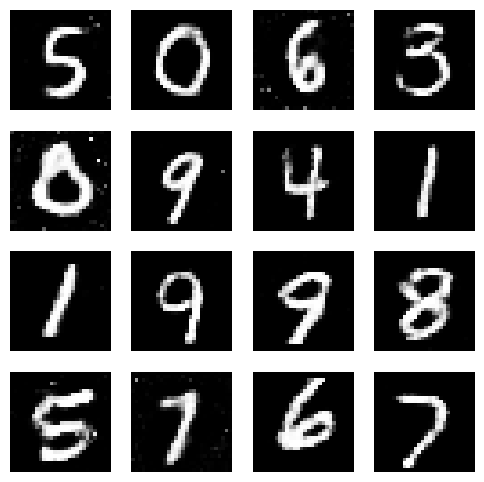

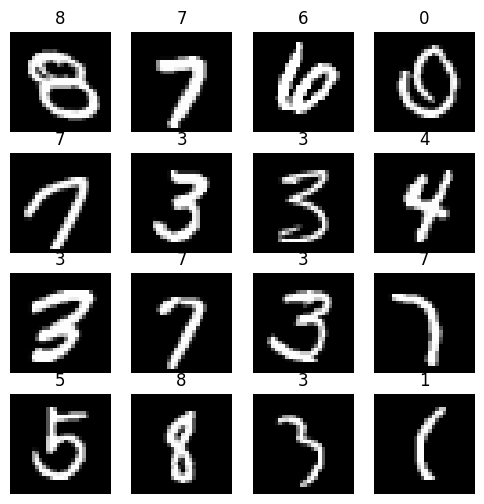

In [29]:
import matplotlib.pyplot as plt

G.eval()

with torch.no_grad():
    noise = fixed_noise
    fake_images = G(noise)

# reshape from [16, 784] to [16, 28, 28]
fake_images = fake_images.view(-1, 28, 28)

# because Generator output is [-1, 1], convert to [0, 1] for display
fake_images = (fake_images + 1) / 2

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake_images[i], cmap="gray")
    plt.axis("off")

plt.show()

G.train()

import matplotlib.pyplot as plt

real_images, real_labels = next(iter(train_loader))

# real_images shape: [64, 1, 28, 28]
real_images = real_images[:16]

# if you normalized with Normalize((0.5,), (0.5,))
# image values are [-1, 1], convert back to [0, 1]
real_images = (real_images + 1) / 2

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(real_images[i].squeeze(), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")

plt.show()

## GAN Training Stability Notes

GANs are harder to train than normal supervised models because two networks are learning against each other:

* **Discriminator D** learns to separate real images from fake images.
* **Generator G** learns to create fake images that fool D.

So the target is constantly moving. If D becomes too strong too quickly, G gets bad gradients and cannot improve. If G improves too fast, D becomes useless. Because of this, GANs need stability tricks.

---

### 1. Adam betas: `betas=(0.5, 0.999)`

Adam keeps moving averages of gradients.

* `beta1` controls momentum from past gradients.
* `beta2` controls momentum from past squared gradients.

Default Adam usually uses:

```python
betas=(0.9, 0.999)
```

For GANs, we often use:

```python
betas=(0.5, 0.999)
```

Reason:

In GANs, the optimization landscape changes constantly because D and G keep changing. Too much old momentum can push the model using outdated gradient information. Lowering `beta1` from `0.9` to `0.5` makes Adam less attached to old gradients and more responsive to the current D/G game.

Gain:

```text
Adam betas → smoother and more stable GAN optimization
```

Example:

```python
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
```

---

### 2. `BCEWithLogitsLoss`

In binary classification, we often use sigmoid + binary cross entropy.

Old version:

```python
D output → Sigmoid → BCELoss
```

Example:

```python
nn.Sigmoid()
loss = nn.BCELoss()
```

Better version:

```python
D output raw logits → BCEWithLogitsLoss
```

Example:

```python
loss = nn.BCEWithLogitsLoss()
```

With this version, the discriminator should **not** end with `Sigmoid`.

Why?

`BCEWithLogitsLoss` combines sigmoid and binary cross entropy internally in a numerically stable way. This is safer when discriminator outputs become very large positive or very large negative values.

Definition:

* **Logit** = raw model score before sigmoid.
* Large positive logit means “real.”
* Large negative logit means “fake.”

Gain:

```text
BCEWithLogitsLoss → safer and more numerically stable binary loss
```

Discriminator final layer should become:

```python
nn.Linear(hidden_dim, 1)
```

not:

```python
nn.Linear(hidden_dim, 1),
nn.Sigmoid()
```

---

### 3. Real label smoothing

Normally discriminator labels are:

```python
real labels = 1.0
fake labels = 0.0
```

With label smoothing, real labels become slightly softer:

```python
real labels = 0.9
fake labels = 0.0
```

Example:

```python
labels_real = torch.full((batch_size, 1), 0.9)
labels_fake = torch.zeros(batch_size, 1)
```

Why?

If D becomes too confident, it may output values extremely close to real/fake certainty. Then G receives weak or unhelpful gradients. Label smoothing prevents D from becoming overconfident too quickly.

Mental model:

```text
Instead of saying "real images must be 1.0,"
we say "real images should be around 0.9."
```

This keeps D slightly softer and gives G a better learning signal.

Gain:

```text
Label smoothing → prevents D from overpowering G
```

---

### Summary

```text
Adam betas=(0.5, 0.999)
→ smoother/stabler optimization for the changing GAN game

BCEWithLogitsLoss
→ safer binary loss because it combines sigmoid + BCE internally

Real label smoothing: 0.9 instead of 1.0
→ prevents D from becoming too confident and overpowering G
```

These tricks do not change the basic GAN idea. They make the D/G fight more balanced, which helps the Generator learn better image distributions.
